In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import (
    interp1d,
    PchipInterpolator,
    CubicSpline,
    Akima1DInterpolator,
)
from scipy.stats import norm, genpareto

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

q : [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
y : [ 7.278  7.677  8.145  8.665  9.25   9.932 10.767 11.885 13.686]


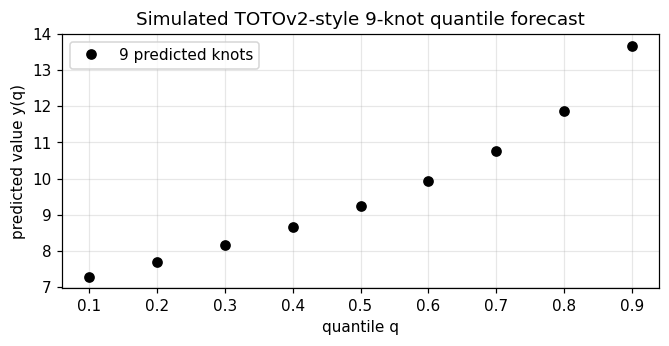

In [2]:
# Knot positions (deciles, as in TOTOv2)
KNOT_QS = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

# Simulate values at those quantiles for a single forecast step.
# We use a slightly skewed distribution so the spline differences are visible.
true_loc, true_scale, skew = 10.0, 2.5, 0.6
z = norm.ppf(KNOT_QS)
KNOT_YS = true_loc + true_scale * (z + skew * (z**2 - 1) / 2)  # mild skew

print("q :", KNOT_QS)
print("y :", np.round(KNOT_YS, 3))

plt.figure(figsize=(7, 3))
plt.plot(KNOT_QS, KNOT_YS, "o", color="black", label="9 predicted knots")
plt.xlabel("quantile q")
plt.ylabel("predicted value y(q)")
plt.title("Simulated TOTOv2-style 9-knot quantile forecast")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [3]:
def _make_tails(qs, ys, kind="gaussian"):
    """
    Build lower/upper tail extrapolation functions fit to the outermost
    two knots on each side. Returns (tail_lo, tail_hi) callables that
    accept a uniform u and return y.

    kind:
      "linear"    — linear extrapolation using the slope of the outer two knots
      "gaussian"  — match a Normal CDF through the outer two knots on each tail
      "exponential" — exponential decay tails (heavier than Gaussian, lighter than Pareto)
    """
    if kind == "linear":
        slope_lo = (ys[1] - ys[0]) / (qs[1] - qs[0])
        slope_hi = (ys[-1] - ys[-2]) / (qs[-1] - qs[-2])
        tail_lo = lambda u: ys[0]  + slope_lo * (u - qs[0])
        tail_hi = lambda u: ys[-1] + slope_hi * (u - qs[-1])

    elif kind == "gaussian":
        z_lo = norm.ppf(qs[:2])
        z_hi = norm.ppf(qs[-2:])
        sigma_lo = (ys[1]  - ys[0])  / (z_lo[1] - z_lo[0])
        mu_lo    = ys[0]  - sigma_lo * z_lo[0]
        sigma_hi = (ys[-1] - ys[-2]) / (z_hi[1] - z_hi[0])
        mu_hi    = ys[-1] - sigma_hi * z_hi[1]
        eps = 1e-9
        tail_lo = lambda u: mu_lo + sigma_lo * norm.ppf(np.clip(u, eps, 1 - eps))
        tail_hi = lambda u: mu_hi + sigma_hi * norm.ppf(np.clip(u, eps, 1 - eps))

    elif kind == "exponential":
        # Lower tail: y(u) = ys[0] - lam_lo * log(qs[0] / u),   u in (0, qs[0]]
        # Upper tail: y(u) = ys[-1] + lam_hi * log((1-qs[-1]) / (1-u)), u in [qs[-1], 1)
        # Fit lam to pass through the second-outermost knot.
        lam_lo = (ys[0]  - ys[1])  / np.log(qs[0]  / qs[1])
        lam_hi = (ys[-1] - ys[-2]) / np.log((1 - qs[-1]) / (1 - qs[-2]))
        eps = 1e-9
        tail_lo = lambda u: ys[0]  - lam_lo * np.log(qs[0]  / np.clip(u, eps, 1.0))
        tail_hi = lambda u: ys[-1] + lam_hi * np.log((1 - qs[-1]) / np.clip(1 - u, eps, 1.0))

    else:
        raise ValueError(f"unknown tail kind: {kind}")

    return tail_lo, tail_hi


def with_tails(interior_factory, tail_kind="gaussian"):
    """
    Wrap an interior interpolator factory so the resulting callable has
    tails on both sides. `interior_factory(qs, ys)` must return a callable
    valid on [qs[0], qs[-1]].
    """
    def factory(qs, ys):
        interior = interior_factory(qs, ys)
        tail_lo, tail_hi = _make_tails(qs, ys, kind=tail_kind)
        def f(u):
            u = np.asarray(u, dtype=float)
            out = np.empty_like(u)
            lo = u < qs[0]
            hi = u > qs[-1]
            mid = ~(lo | hi)
            if mid.any():
                out[mid] = interior(u[mid])
            if lo.any():
                out[lo] = tail_lo(u[lo])
            if hi.any():
                out[hi] = tail_hi(u[hi])
            return out
        return f
    return factory


# Interior-only factories (each returns a callable defined on [0.1, 0.9])
def _interior_linear(qs, ys):
    return interp1d(qs, ys, kind="linear", bounds_error=False,
                    fill_value=(ys[0], ys[-1]))

def _interior_pchip(qs, ys):
    return PchipInterpolator(qs, ys, extrapolate=False)

def _interior_akima(qs, ys):
    return Akima1DInterpolator(qs, ys)

def _interior_cubic(qs, ys):
    return CubicSpline(qs, ys, bc_type="natural", extrapolate=False)


# Choose a tail family for the comparison. Try swapping this to
# "linear" or "exponential" to see how tail choice affects sampling.
TAIL_KIND = "gaussian"

METHODS = {
    "Linear + linear tails":              with_tails(_interior_linear, "linear"),
    f"Linear + {TAIL_KIND} tails":        with_tails(_interior_linear, TAIL_KIND),
    f"PCHIP + {TAIL_KIND} tails":         with_tails(_interior_pchip,  TAIL_KIND),
    f"Akima + {TAIL_KIND} tails":         with_tails(_interior_akima,  TAIL_KIND),
    f"Natural cubic + {TAIL_KIND} tails": with_tails(_interior_cubic,  TAIL_KIND),
    "PCHIP + exponential tails":          with_tails(_interior_pchip,  "exponential"),
}

Linear + linear tails              23.39 µs / fit
Linear + gaussian tails           189.85 µs / fit
PCHIP + gaussian tails            328.64 µs / fit
Akima + gaussian tails            285.30 µs / fit
Natural cubic + gaussian tails    291.91 µs / fit
PCHIP + exponential tails         159.97 µs / fit


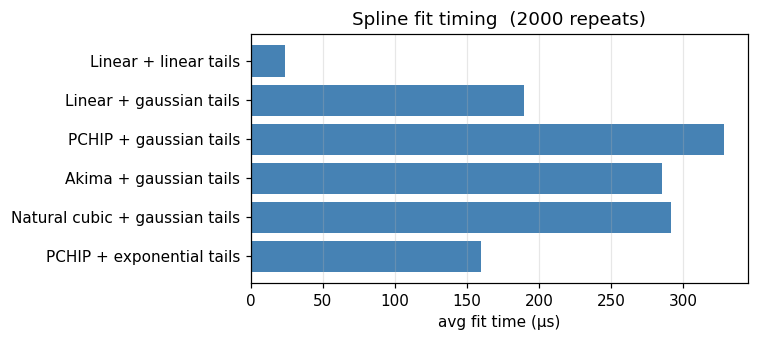

In [4]:
N_REPEATS = 2000  # repeats to get a stable timing
timings = {}

for name, fit_fn in METHODS.items():
    t0 = time.perf_counter()
    for _ in range(N_REPEATS):
        f = fit_fn(KNOT_QS, KNOT_YS)
    t1 = time.perf_counter()
    avg_us = (t1 - t0) / N_REPEATS * 1e6
    timings[name] = avg_us
    print(f"{name:30s}  {avg_us:8.2f} µs / fit")

plt.figure(figsize=(7, 3.2))
names = list(timings.keys())
vals = [timings[n] for n in names]
plt.barh(names, vals, color="steelblue")
plt.xlabel("avg fit time (µs)")
plt.title(f"Spline fit timing  ({N_REPEATS} repeats)")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
from uni2ts.module.distributions import QuantileKnotDistribution
B, T, K = 128, 256, 9
ys = KNOT_YS + 0.5 * np.random.randn(B, T, K).cumsum(axis=-1)
ys.sort(axis=-1)

# Fit time (one batched fit covers all 128*256 = 32,768 distributions)
N_REPEATS = 200
for tails in ("linear", "gaussian"):
    t0 = time.perf_counter()
    for _ in range(N_REPEATS):
        d = QuantileKnotDistribution(tails=tails).fit(KNOT_QS, ys)
    t1 = time.perf_counter()
    fit_ms = (t1 - t0) / N_REPEATS * 1e3
    # Sample time
    t0 = time.perf_counter()
    for _ in range(N_REPEATS):
        _ = d.rvs(random_state=0)
    t1 = time.perf_counter()
    rvs_ms = (t1 - t0) / N_REPEATS * 1e3
    print(f"  tails={tails:8s}  fit: {fit_ms:6.2f} ms   rvs: {rvs_ms:6.2f} ms   "
          f"(per-distribution fit ≈ {fit_ms*1000/(B*T):.2f} µs)")

/srv/disk00/ctadler/uni2ts/src/uni2ts/module/distributions.py:93: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u = torch.tensor(u)


  tails=linear    fit:   0.75 ms   rvs:   1.41 ms   (per-distribution fit ≈ 0.02 µs)
  tails=gaussian  fit:   1.02 ms   rvs:   1.60 ms   (per-distribution fit ≈ 0.03 µs)


In [6]:
N_EVAL = 10_000   # number of u draws to evaluate per call
N_REPEATS_EVAL = 500
u_grid = np.random.uniform(0.0, 1.0, size=N_EVAL)

eval_timings = {}
for name, fit_fn in METHODS.items():
    f = fit_fn(KNOT_QS, KNOT_YS)
    # Some scipy interpolators raise on out-of-domain; clip to be fair.
    u_safe = np.clip(u_grid, KNOT_QS[0], KNOT_QS[-1]) if "tails" not in name and name != "Linear (no tails)" else u_grid
    t0 = time.perf_counter()
    for _ in range(N_REPEATS_EVAL):
        _ = f(u_safe)
    t1 = time.perf_counter()
    avg_us = (t1 - t0) / N_REPEATS_EVAL * 1e6
    eval_timings[name] = avg_us
    print(f"{name:30s}  {avg_us:9.2f} µs / {N_EVAL} evaluations")

Linear + linear tails              308.56 µs / 10000 evaluations
Linear + gaussian tails            567.80 µs / 10000 evaluations
PCHIP + gaussian tails             620.04 µs / 10000 evaluations
Akima + gaussian tails             612.08 µs / 10000 evaluations
Natural cubic + gaussian tails     610.20 µs / 10000 evaluations
PCHIP + exponential tails          374.59 µs / 10000 evaluations


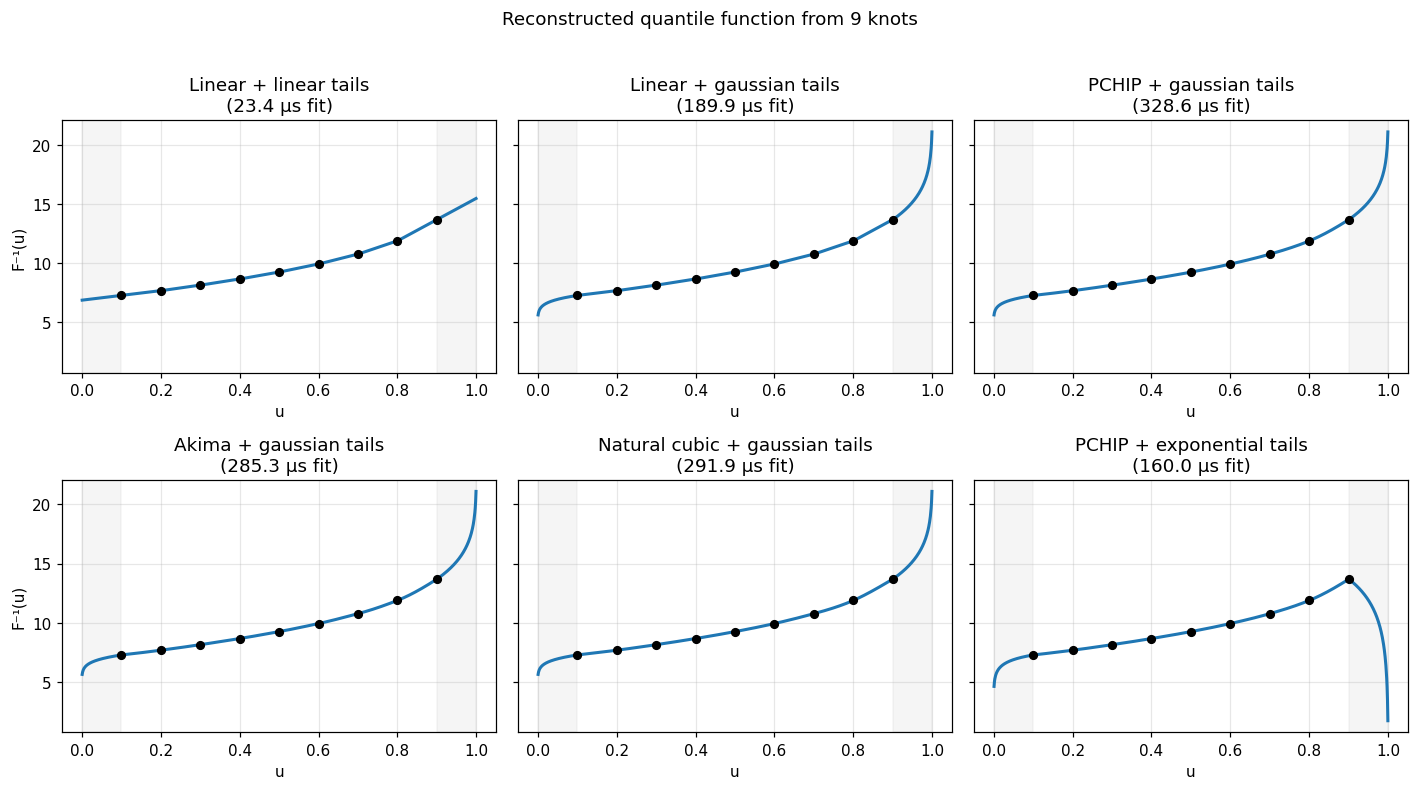

In [7]:
u_dense = np.linspace(0.001, 0.999, 1001)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, (name, fit_fn) in zip(axes.flat, METHODS.items()):
    f = fit_fn(KNOT_QS, KNOT_YS)
    try:
        y_dense = f(u_dense)
    except ValueError:
        y_dense = np.full_like(u_dense, np.nan)
    ax.plot(u_dense, y_dense, lw=2, color="C0", label=name)
    ax.plot(KNOT_QS, KNOT_YS, "o", color="black", ms=5, label="knots")
    ax.axvspan(0, KNOT_QS[0], color="grey", alpha=0.08)
    ax.axvspan(KNOT_QS[-1], 1, color="grey", alpha=0.08)
    ax.set_title(f"{name}\n({timings[name]:.1f} µs fit)")
    ax.set_xlabel("u")
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("F⁻¹(u)")
axes[1, 0].set_ylabel("F⁻¹(u)")
plt.suptitle("Reconstructed quantile function from 9 knots", y=1.02)
plt.tight_layout()
plt.show()

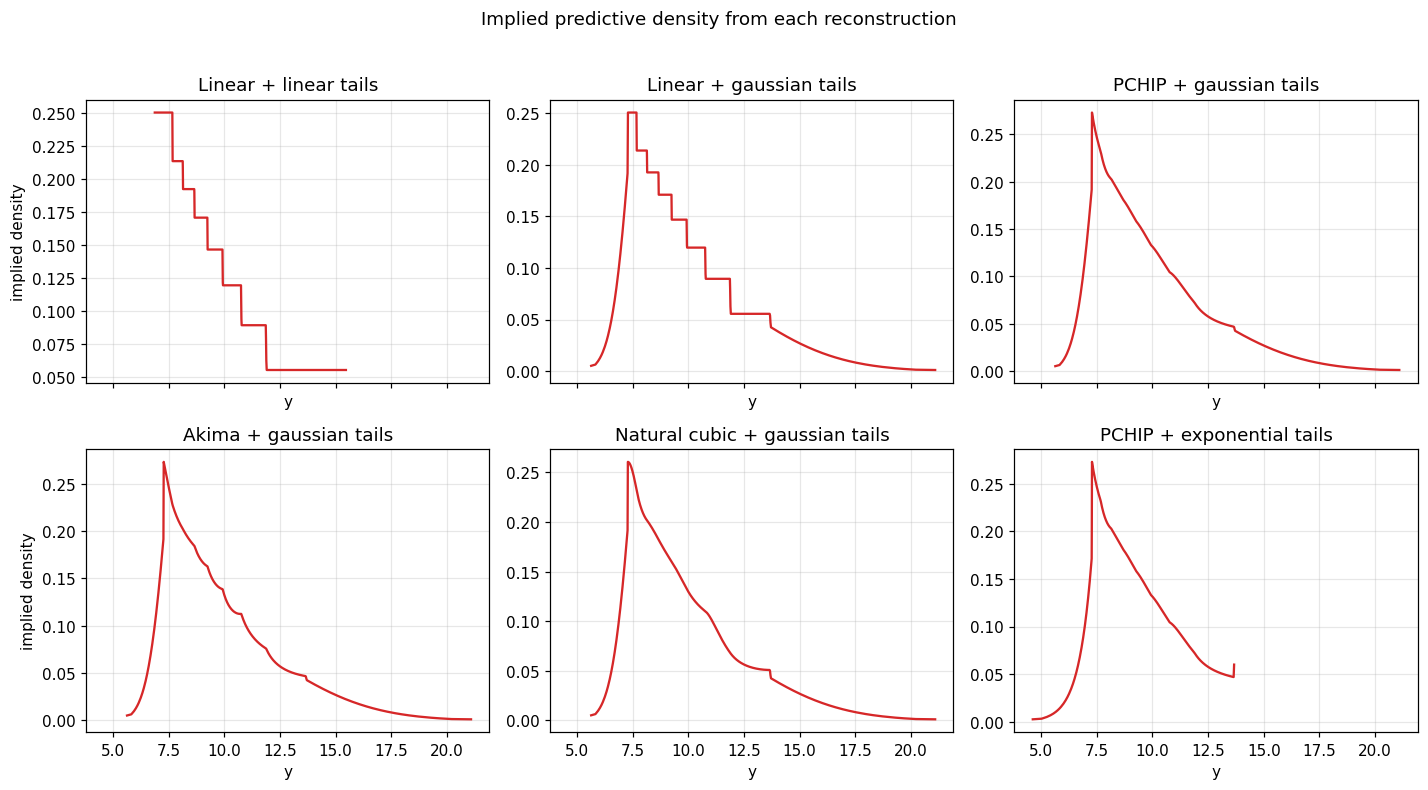

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for ax, (name, fit_fn) in zip(axes.flat, METHODS.items()):
    f = fit_fn(KNOT_QS, KNOT_YS)
    try:
        y_dense = f(u_dense)
    except ValueError:
        continue
    # density f(y) = 1 / (dF^{-1}/du)
    dydu = np.gradient(y_dense, u_dense)
    pdf = 1.0 / np.where(dydu > 0, dydu, np.nan)
    ax.plot(y_dense, pdf, color="C3")
    ax.set_title(name)
    ax.set_xlabel("y")
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("implied density")
axes[1, 0].set_ylabel("implied density")
plt.suptitle("Implied predictive density from each reconstruction", y=1.02)
plt.tight_layout()
plt.show()

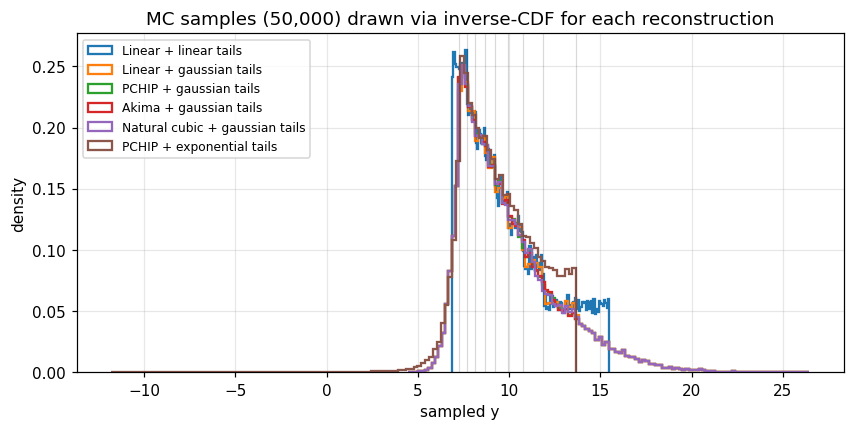

In [9]:
N_SAMPLES = 50_000
u = np.random.uniform(0.0, 1.0, size=N_SAMPLES)

fig, ax = plt.subplots(figsize=(9, 4))
for name, fit_fn in METHODS.items():
    f = fit_fn(KNOT_QS, KNOT_YS)
    if "tails" not in name and name != "Linear (no tails)":
        u_use = np.clip(u, KNOT_QS[0], KNOT_QS[-1])
    else:
        u_use = u
    samples = f(u_use)
    samples = samples[np.isfinite(samples)]
    ax.hist(samples, bins=120, density=True, histtype="step", lw=1.5, label=name)

for q, y in zip(KNOT_QS, KNOT_YS):
    ax.axvline(y, color="black", alpha=0.15, lw=0.8)
ax.set_xlabel("sampled y")
ax.set_ylabel("density")
ax.set_title(f"MC samples ({N_SAMPLES:,}) drawn via inverse-CDF for each reconstruction")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.show()